In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re 
import string
import nltk
from nltk.tokenize import word_tokenize 
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from contractions import fix
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score
from collections import Counter

In [7]:
df=pd.read_csv(r'C:/Users/DELL/Downloads/mail_data.csv')

In [8]:
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [9]:
lemmatizer=WordNetLemmatizer()
encoder=LabelEncoder()
stop_word=set(stopwords.words('english'))
smote=SMOTE(random_state=42)
model=MultinomialNB()
vectorizer=CountVectorizer(stop_words='english',max_features=5000)

In [10]:
nltk.download('punkt')
nltk.download('stopword')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Error loading stopword: Package 'stopword' not found in
[nltk_data]     index
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# Text preprocessing

In [11]:
def clean_text(text):
    text=fix(text)
    text=text.lower()
    text=re.sub(r'http\S+','URL',text)
    text=re.sub('<.*?>','',text)
    text=re.sub('\d+','NUM',text)
    text=text.translate(str.maketrans('','',string.punctuation))
    words=word_tokenize(text)
    clean=[lemmatizer.lemmatize(word) for word in words if word not in stop_word]
    return " ".join(clean)

In [12]:
df.loc[:,'Message']=df['Message'].apply(clean_text)

In [13]:
for i in range(100):
    print(df['Message'][i])

go jurong point crazy available bugis n great world la e buffet cine got amore wat
ok lar joking wif oni
free entry NUM wkly comp win fa cup final tkts NUMst may NUM text fa NUM receive entry questionstd txt ratetcs apply NUMoverNUMs
dun say early hor c already say
nah think go usf life around though
freemsg hey darling NUM week word back would like fun still tb ok xxx std chgs send £NUMNUM rcv
even brother like speak treat like aid patent
per request melle melle oru minnaminunginte nurungu vettam set callertune caller press NUM copy friend callertune
winner valued network customer selected receivea £NUM prize reward claim call NUM claim code klNUM valid NUM hour
mobile NUM month r entitled update latest colour mobile camera free call mobile update co free NUM
going home soon want talk stuff anymore tonight k cried enough today
six chance win cash NUM NUMNUM pound txt cshNUM send NUM cost NUMpday NUMdays NUM tsandcs apply reply hl NUM info
urgent NUM week free membership £NUMNUM prize 

In [14]:
y=encoder.fit_transform(df['Category'])

In [15]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5572,))

In [16]:
X=vectorizer.fit_transform(df['Message']).toarray()

In [17]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(5572, 5000))

In [18]:
X=pd.DataFrame(X)

In [19]:
X

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5567,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5568,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5569,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5570,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


<Axes: title={'center': 'before SMOTE'}>

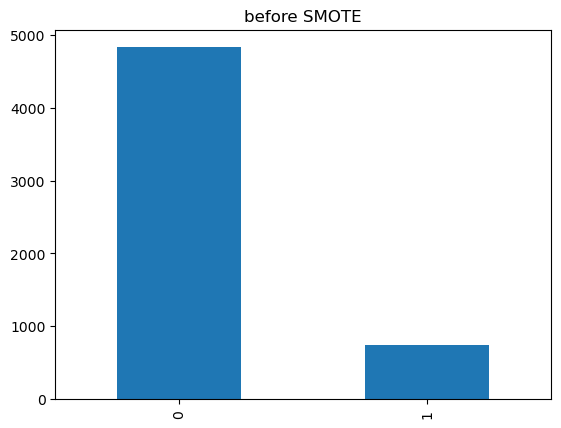

In [42]:
pd.Series(y).value_counts().plot(kind='bar',title='before SMOTE')

# Sampling by SMOTE

In [20]:
X_resampled,y_resampled=smote.fit_resample(X,y)

In [21]:
print('Before :', Counter(y))
print('After :',Counter(y_resampled))

Before : Counter({np.int64(0): 4825, np.int64(1): 747})
After : Counter({np.int64(0): 4825, np.int64(1): 4825})


<Axes: title={'center': 'After SMOTE'}>

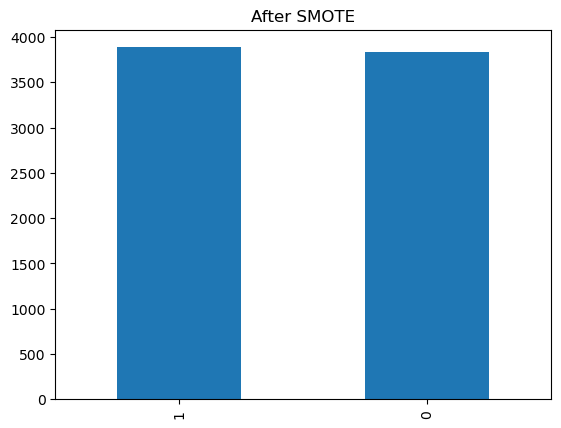

In [43]:
pd.Series(y_train).value_counts().plot(kind='bar',title='After SMOTE')

# Train Test split use

In [22]:
X_train,X_test,y_train,y_test=train_test_split(X_resampled,y_resampled,test_size=0.2,random_state=42)

In [23]:
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(7720, 5000) (1930, 5000) (7720,) (1930,)


# Train Model

In [24]:
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [25]:
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

0.9803108808290155
0.9678423236514523
[[959  31]
 [  7 933]]


In [26]:
def prediction(text):
    text=clean_text(text)
    Num_text=vectorizer.transform([text])
    result=model.predict(Num_text)
    if result==1:
        print('Spam')
    else:
        print('Ham')

In [27]:
prediction('Earn $50000 per day from home without any investment. join now!')

Ham


In [28]:
prediction('Free recharge worth $199. Click this link to activete.')

Spam


In [29]:
prediction('Get cheap loans instantly. NO documents required!')

Ham


In [30]:
prediction("Please send me the notes of today's class.")

Ham


In [33]:
train_acc=model.score(X_resampled,y_resampled)
test_acc=model.score(X_test,y_test)

In [34]:
print(f"Train Accuracy : {train_acc :.3f}")
print(f"test Accuracy : {test_acc :.3f}")

Train Accuracy : 0.979
test Accuracy : 0.980


In [35]:
from sklearn.model_selection import cross_val_score
cv_scores=cross_val_score(model,X_train,y_train,cv=5)
print(f"CV Accuracy :{cv_scores.mean():.3f},{cv_scores.std():.3f}")

CV Accuracy :0.974,0.002


In [36]:
prediction('Congratulations! You have won $1000000. Click here to claim now.')

Spam


In [37]:
prediction('Hurry up! Limited time offer, buy now and get 90% discount.')

Spam


In [38]:
prediction('You have been selected for a free iPhone Provide your details.')

Spam


In [39]:
prediction('Click this link to update your kyc urgently')

Spam


In [40]:
prediction('Lowest price sale! 80% off on all items')

Spam


In [41]:
prediction('Your account will be blocked. Verify immediately http://fake-link.com ')

Spam


In [44]:
prediction('Dear user, Your bank account will be blocked. Verify immediatelyat http://secure-bank-login.com.')

Spam


In [45]:
prediction('Get instant loan approved in 5 minutes No documents required. Apply now!!!')

Spam
